# Module 1: Deep Agents

> Part of the **Modular Workshops** series. Standalone, ~45 min.

Deep Agents = `create_agent()` + a pre-built middleware stack (filesystem, planning, subagents, context management). We'll build up from a bare agent to a fully-featured research assistant, exploring:

- The harness and built-in tools
- Custom tools (Tavily search)
- Subagents and context isolation
- Backends and persistent memory
- Middleware (compliance, audit)
- Human-in-the-loop on tool calls
- AGENTS.md and Skills


## Setup

In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.models import model

from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command
from langsmith import uuid7
from IPython.display import Image, display

print("Ready")


Ready


---
# Part 1: Deep Agents

Deep Agents = `create_agent()` + a pre-built middleware stack (filesystem, planning, subagents, context management).

We'll build up from a bare agent to a fully-featured research assistant.

## 1.1 Your First Deep Agent

`create_deep_agent()` gives you a filesystem, a todo list, and context management out of the box — no tools required.

<img src="../images/deepAgentsDiag.png" style="width: auto; max-height: 420px; border-radius: 8px;">

### What you get for free:

- **Filesystem Tools** — `ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`
- **Planning Tool** — `write_todos` for task tracking
- **Subagent Delegation** — `task()` tool for isolated work
- **Large Tool Result Eviction** — Automatically offloads tool results >20k tokens to the filesystem
- **Conversation Summarization** — Compresses history when approaching ~85% context capacity
- **Dangling Tool Call Patching** — Fixes message history consistency automatically


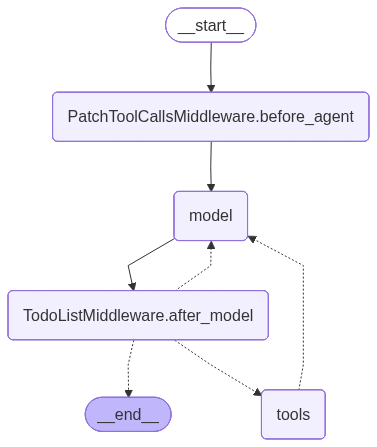

In [2]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    model=model,
    system_prompt="You are a helpful assistant.",
    checkpointer=MemorySaver(),
)
agent

In [3]:
# The agent can already write and read files — these are built-in tools
config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Write a haiku about AI to /haiku.txt, then read it back to me."}]
}, config=config)

print(result["messages"][-1].content)

Silent thoughts arise,
Machine dreams weave through the night,
Code breathes life anew.


In [4]:
# Helper: print the virtual filesystem from a deep agent result.
def print_files(result, header="VIRTUAL FILESYSTEM (in-memory, not on disk!)"):
    files = result.get("files") or {}
    if not files:
        print("(no files in state)")
        return
    print("=" * 50)
    print(header)
    print("=" * 50)
    for path, file_data in files.items():
        print(f"\n  Path: {path!r}")
        print("  " + "-" * 38)
        content = file_data
        if isinstance(file_data, dict) and "content" in file_data:
            content = file_data["content"]
        if isinstance(content, list):
            content = "\n".join(content)
        for line in str(content).split("\n"):
            print(f"  | {line}")

print_files(result)


VIRTUAL FILESYSTEM (in-memory, not on disk!)

  Path: '/haiku.txt'
  --------------------------------------
  | Silent thoughts arise,
  | Machine dreams weave through the night,
  | Code breathes life anew.


### Filesystem persistence within a thread

By default, `create_deep_agent()` uses **StateBackend** — files are stored in agent state and persist within a thread (via the checkpointer), but disappear when you start a new thread.

| Backend | Storage | Persistence | Use Case |
|---------|---------|-------------|----------|
| **StateBackend** | In-memory (agent state) | Single thread | Scratch pads, intermediate results |
| **FilesystemBackend** | Local disk | Permanent | Direct file access (use with caution) |
| **StoreBackend** | LangGraph Store | Cross-thread | Long-term memories |
| **CompositeBackend** | Routes to others | Mixed | Selective persistence |

In [5]:
# Same thread — the file persists via the checkpointer
result = agent.invoke({
    "messages": [{"role": "user", "content": "Read the file /haiku.txt"}]
}, config=config)

print("Same thread:", result["messages"][-1].content)

Same thread: The content of /haiku.txt is:

Silent thoughts arise,
Machine dreams weave through the night,
Code breathes life anew.


In [6]:
# New thread — StateBackend is ephemeral, so the file is gone
new_config = {"configurable": {"thread_id": str(uuid7())}}

result = agent.invoke({
    "messages": [{"role": "user", "content": "List all files with ls /"}]
}, config=new_config)

print("New thread:", result["messages"][-1].content)

New thread: The root directory (/) is empty and contains no files or folders.


### Key Takeaway
- `create_deep_agent()` gives you filesystem + planning capabilities for free
- Files are stored in agent state (virtual, not on disk)
- `StateBackend` (default) persists within a thread but is ephemeral across threads
- We'll see how to make files persist across threads with `CompositeBackend` + `StoreBackend` in section 1.4

## 1.2 Custom Tools

Add your own tools alongside the built-in ones. We define `tavily_search` inline with `@tool` so the pattern stays visible; the body delegates to `resilient_tavily_search` from `utils/search.py`, which retries on Tavily failure and falls back to a canned response so the demo doesn't break on a flaky network.


In [7]:
from utils.search import resilient_tavily_search

@tool(parse_docstring=True)
def tavily_search(query: str) -> str:
    """Search the web for information on a given query.

    Args:
        query: Search query to execute.
    """
    # `resilient_tavily_search` retries on Tavily failure and falls back to a
    # topic-matched canned response. See utils/search.py.
    return resilient_tavily_search(query, max_retries=2)

agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful research assistant.",
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "What is Deep Agents? Write a one-paragraph summary to /summary.md"}]
}, config=config)

print("Agent reply:", result["messages"][-1].content)
print()
print_files(result)


Agent reply: Deep Agents are advanced AI assistants designed to help users accomplish tasks efficiently using a variety of integrated tools. They operate by understanding the user's intent, acting on it through the appropriate tools, and verifying the results to ensure accuracy and completeness. Deep Agents are capable of managing complex, multi-step objectives by breaking them down into smaller tasks, tracking progress, and optimizing parallel execution when possible. Their core behavior emphasizes professional objectivity, concise communication, and proactive problem-solving, making them effective for both simple and highly intricate tasks across different domains.

VIRTUAL FILESYSTEM (in-memory, not on disk!)

  Path: '/summary.md'
  --------------------------------------
  | Deep Agents are advanced AI assistants designed to help users accomplish tasks efficiently using a variety of integrated tools. They operate by understanding the user's intent, acting on it through the appropri

## 1.3 Subagents: Isolated Delegation

Subagents run in a separate context. The main agent delegates via `task()` and only sees the final result — keeping the main context clean.

<img src="../images/deepAgentSubagents.png" style="width: auto; max-height: 380px; border-radius: 8px;">


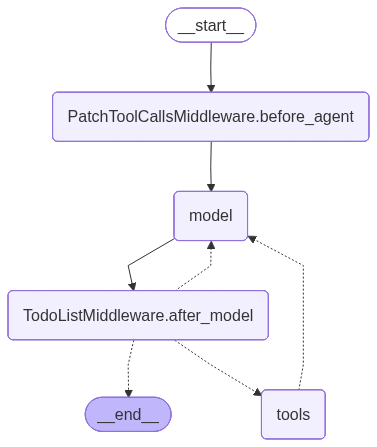

In [8]:
from datetime import datetime

research_subagent = {
    "name": "research-agent",
    "description": "Delegate research tasks. Give one topic at a time.",
    "system_prompt": f"""You are a research assistant. Today is {datetime.now().strftime('%Y-%m-%d')}.
Use tools to gather information. Structure findings with clear headings and inline citations.
Limit to 3 search calls.""",
    "tools": [tavily_search],
}

agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="""You are a research coordinator.
Delegate research to the research-agent using the task() tool.
NEVER search directly — always delegate.
Synthesize findings and write a report.""",
    subagents=[research_subagent],
    checkpointer=MemorySaver(),
)
agent

In [9]:
config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Lightly research the latest news on AI agents this week"}]
}, config=config)

print(result["messages"][-1].content[:1500])

Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c5-25a1-7b43-90f3-afbe1b6d1ed5.')
Error in LangChainTracer.on_llm_end callback: TracerException('No indexed run ID 019e89c5-25cb-7643-9970-f190aa45ef85.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c5-25a5-7b50-b36a-0032230aa426.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c5-2aa5-71f1-8119-92c3a6747e93.')
Error in LangChainTracer.on_tool_end callback: TracerException('No indexed run ID 019e89c5-2aa9-7a02-97fe-e0afc5465ebc.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c5-2aa7-7731-8cec-a2fde5d0b43d.')
Error in LangChainTracer.on_llm_end callback: TracerException('No indexed run ID 019e89c5-306d-7ee1-8719-4e9ecf260e9e.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c5-303d-7723-b9fd-c0c00e1d752d.')
Error in LangChainTra

Here's a concise update on the latest news and trends about AI agents this week (June 2026):

1. Enterprise AI agent stack evolves with acquisitions like StackAI (no-code builder) and Palo Alto Networks’ Portkey (security layer), focusing on execution and security.
2. Salesforce’s Agentforce platform advances responsible AI agent behavior with scripting, session tracing, and behavioral drift detection.
3. Multi-step agent workflows are widely adopted (57% orgs) with a shift towards embedding AI within business processes.
4. AI agent architectures cover perception, reasoning, planning, memory, action, and orchestration, addressing challenges like hallucinations and security.
5. Several AI agent conferences are scheduled globally in 2026-2027, signaling strong ecosystem growth.
6. IBM promotes AI agents as autonomous systems and emphasizes the productivity gains from orchestration across enterprise technology stacks.
7. Industry attention on hybrid human-agent workforce models, governanc

## 1.4 Backends & Memory

By default, files live in ephemeral state (`StateBackend`). Use `CompositeBackend` to route paths — e.g. `/memories/` to persistent `StoreBackend` while everything else stays ephemeral.

<img src="../images/deepAgentBackends.png" style="width: auto; max-height: 380px; border-radius: 8px;">


In [10]:
from deepagents.backends import StateBackend, StoreBackend, CompositeBackend
from langgraph.store.memory import InMemoryStore

store = InMemoryStore()

# Pass a CompositeBackend *instance* (not a factory). The namespace stays a
# callable so StoreBackend can read the current Runtime when scoping memory.
backend = CompositeBackend(
    default=StateBackend(),                                  # ephemeral scratch space
    routes={
        "/memories/": StoreBackend(                          # persists across threads
            store=store,
            namespace=lambda rt: ("memories", "shared"),
        ),
    },
)

agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt=(
        "You are a helpful assistant. Save important facts to /memories/ for future reference. "
        "ALWAYS check /memories files before answering any questions to ensure you don't miss relevant information."
    ),
    subagents=[research_subagent],
    backend=backend,
    store=store,
    checkpointer=MemorySaver(),
)

# Thread 1: agent saves a memory
config1 = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Remember that my favorite programming language is Python. Save this to /memories/preferences.md"}]
}, config=config1)
print("Thread 1:", result["messages"][-1].content)


Thread 1: I have saved that your favorite programming language is Python to /memories/preferences.md.


In [11]:
# Thread 2: different thread, but /memories/ persists via StoreBackend
config2 = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "What's my favorite programming language? Check /memories/"}]
}, config=config2)
print("Thread 2:", result["messages"][-1].content)

Thread 2: Your favorite programming language is Python.


## 1.5 Middleware: Pluggable Behavior

Middleware hooks into `wrap_model_call` (every LLM call) and `wrap_tool_call` (every tool call). This lets you inject rules, audit, or intercept without changing agent code.

<img src="../images/deepAgentMiddleware.png" style="width: auto; max-height: 380px; border-radius: 8px;">

### Built-in context management

Three strategies the deep-agent middleware uses to keep within the model's context window:

<img src="../images/Offloading Inputs LangChain.png" style="width: auto; max-height: 240px; border-radius: 8px;">

**Offload Large Inputs** — file write/edit tool calls leave the full content in conversation history. At ~85% context capacity, deep agents truncate older tool calls and replace them with a file-pointer reference.

<img src="../images/Offloading Results LangChain.png" style="width: auto; max-height: 240px; border-radius: 8px;">

**Offload Large Results** — tool results over ~20k tokens are written to the backend and swapped with a path + 10-line preview. The agent can re-read or grep the full content as needed.

<img src="../images/LangChain Summarization.png" style="width: auto; max-height: 240px; border-radius: 8px;">

**Conversation Summarization** — when there's nothing left to offload and context hits ~85% of `max_input_tokens`, history is summarized. Full messages move to `/conversation_history/`; a structured summary replaces them in working memory.


In [12]:
from langchain.agents.middleware import wrap_model_call, wrap_tool_call
from langchain_core.messages import SystemMessage

audit_log = []

@wrap_model_call
def compliance_rules(request, handler):
    """Inject compliance rules into every LLM call."""
    rules = """## Compliance Rules
- Never include SSNs, credit card numbers, or account passwords in responses
- Always cite sources when presenting research findings
- Flag any request involving non-public financial information"""
    existing = request.system_message
    blocks = list(existing.content_blocks) if existing else []
    blocks.append({"type": "text", "text": f"\n\n{rules}"})
    return handler(request.override(system_message=SystemMessage(content_blocks=blocks)))

@wrap_tool_call
def audit_trail(request, handler):
    """Create an audit log entry for every tool call."""
    entry = {"tool": request.tool_call["name"], "timestamp": datetime.now().isoformat()}
    result = handler(request)
    entry["status"] = "success"
    audit_log.append(entry)
    return result

agent_with_middleware = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful research assistant.",
    middleware=[compliance_rules, audit_trail],
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent_with_middleware.invoke({
    "messages": [{"role": "user", "content": "What is LangGraph? Write a short summary to /summary.md"}]
}, config=config)

print(result["messages"][-1].content)
print(f"\n--- Audit Log ({len(audit_log)} entries) ---")
for entry in audit_log:
    print(f"  {entry['timestamp']}  {entry['tool']}  {entry['status']}")

LangGraph is a framework designed to facilitate the creation and management of applications based on large language models (LLMs). It provides tools and abstractions to build complex workflows and integrate multiple components, enabling developers to construct advanced AI-driven solutions more efficiently. The summary has been written to /summary.md.

--- Audit Log (1 entries) ---
  2026-06-02T15:18:05.980165  write_file  success


## 1.6 HITL: Tool-Level Approval

Deep Agents supports `interrupt_on` — pause execution when specific tools are called. The human can approve, edit, or reject.

<img src="../images/deepAgentHITL.png" style="width: auto; max-height: 380px; border-radius: 8px;">


In [13]:
agent_with_hitl = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful research assistant.",
    checkpointer=MemorySaver(),
    interrupt_on={
        "write_file": True,
        "edit_file": True,
    },
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent_with_hitl.invoke({
    "messages": [{"role": "user", "content": "Write a file called /test.md with 'Hello World'"}]
}, config=config)

if result.get("__interrupt__"):
    interrupt_info = result["__interrupt__"][0].value
    for action in interrupt_info["action_requests"]:
        print(f"Paused — tool: {action['name']}, args: {action['args']}")
    print("\nWaiting for approval...")

Paused — tool: write_file, args: {'file_path': '/test.md', 'content': 'Hello World'}

Waiting for approval...


In [14]:
# Approve and continue
if result.get("__interrupt__"):
    result = agent_with_hitl.invoke(
        Command(resume={"decisions": [{"type": "approve"}]}),
        config=config,
    )
    print("Approved!")
    print("Agent reply:", result["messages"][-1].content)
    print()
    print_files(result)


Approved!
Agent reply: Created file /test.md with content: Hello World

VIRTUAL FILESYSTEM (in-memory, not on disk!)

  Path: '/test.md'
  --------------------------------------
  | Hello World


## 1.7 AGENTS.md & Skills

`AGENTS.md` replaces hardcoded system prompts with an editable identity file. Skills are loaded on demand — the agent reads them only when the task matches.

In [15]:
from deepagents.backends.utils import create_file_data

agents_md = """# Research Assistant

You are an expert research assistant.

## Workflow
1. Plan with write_todos
2. Delegate research to research-agent via task()
3. Synthesize findings into a report
4. Save to /final_report.md

## Rules
- Delegate research, don't search directly
- Consolidate citations [1], [2], [3]
- Check /skills/ for content format instructions
"""

linkedin_skill = """---
name: linkedin-post
description: Write a LinkedIn post. Use when asked for LinkedIn content or thought leadership.
---

# LinkedIn Post Skill

- Bold hook as first line (before the "see more" cut)
- 3-5 short paragraphs with 1-2 emojis each
- End with a CTA or question
- 3-5 hashtags at the bottom
- 150-300 words
"""

# The agent's identity lives in the /AGENTS.md file (seeded below) and is loaded
# via the `memory` parameter — no redundant `system_prompt` string.
agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    subagents=[research_subagent],
    memory=["/AGENTS.md"],
    skills=["/skills/"],
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": uuid7()}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Research AI agents briefly, then write a LinkedIn post about it."}],
    "files": {
        "/AGENTS.md": create_file_data(agents_md),
        "/skills/linkedin-post/SKILL.md": create_file_data(linkedin_skill),
    },
}, config=config)

print(result["messages"])

# Ignore final to-do
print(result["messages"][-4].content[:1500])

Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c5-9f7d-7a62-a904-bdb90a898a26.')
Error in LangChainTracer.on_llm_end callback: TracerException('No indexed run ID 019e89c5-9fa9-7582-aa87-4bc7c0dbafad.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c5-9f80-7953-aea3-3e6bb973b5ea.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c5-a2d4-7f83-8718-a99f81f3cd36.')
Error in LangChainTracer.on_tool_end callback: TracerException('No indexed run ID 019e89c5-a2d8-7600-a5b5-e81f7e2d7c90.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c5-a2d6-7010-82fa-fcf414fb083e.')
Error in LangChainTracer.on_llm_end callback: TracerException('No indexed run ID 019e89c5-a5f7-7442-a37c-6639822e640e.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c5-a5c7-7742-bbf6-98cfe57d03ab.')
Error in LangChainTra

[HumanMessage(content='Research AI agents briefly, then write a LinkedIn post about it.', additional_kwargs={}, response_metadata={}, id='e99be5e3-dc0b-4f16-8799-161c38a292aa'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 6993, 'total_tokens': 7057, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_a1fb391a6a', 'id': 'chatcmpl-DmOun9IROpl2EgMtcR4rrF9Ptwb7f', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e89c5-99ac-7a80-a1bf-35d8665c255e-0', tool_calls=[{'name': 'task', 'args': {'description': 'Research AI agents briefly. Identify key concepts, recent developments, and potential impacts in the field. Summ

## 1.8 The Complete Agent

All pieces together: tools, subagents, memory, middleware, HITL, AGENTS.md, and skills.

> `agents/research_agent.py` packages a minimal slice of this (no HITL, no FilesystemBackend) for Module 4's evals.


In [16]:
store = InMemoryStore()
audit_log = []  # reset

complete_backend = CompositeBackend(
    default=StateBackend(),
    routes={
        "/memories/": StoreBackend(
            store=store,
            namespace=lambda rt: ("memories", "shared"),
        ),
    },
)

complete_agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    subagents=[research_subagent],
    backend=complete_backend,
    store=store,
    middleware=[compliance_rules, audit_trail],
    checkpointer=MemorySaver(),
    interrupt_on={"write_file": True, "edit_file": True},
    memory=["/AGENTS.md"],
    skills=["/skills/"],
)

print("Complete agent created with:")
print("  - Custom tools (tavily_search)")
print("  - Subagents (research-agent)")
print("  - Memory (/memories/ -> StoreBackend)")
print("  - Middleware (compliance rules + audit trail)")
print("  - HITL (interrupt on file writes)")
print("  - AGENTS.md + Skills")

Complete agent created with:
  - Custom tools (tavily_search)
  - Subagents (research-agent)
  - Memory (/memories/ -> StoreBackend)
  - Middleware (compliance rules + audit trail)
  - HITL (interrupt on file writes)
  - AGENTS.md + Skills


In [17]:
# Drive the complete agent end-to-end.
# Exercises: subagent delegation, file writes (HITL-gated),
# /memories/ persistence, and middleware (audit + compliance).
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": str(uuid7())}}

# Seed AGENTS.md + the LinkedIn skill (same content as the 1.7 cell)
# so the agent has its identity and capabilities loaded.
seed_files = {
    "/AGENTS.md": create_file_data(agents_md),
    "/skills/linkedin-post/SKILL.md": create_file_data(linkedin_skill),
}

result = complete_agent.invoke({
    "messages": [HumanMessage(content=(
        "Research the LangChain v1 release briefly. "
        "Follow your AGENTS.md workflow: delegate research, write the final report to /final_report.md, "
        "and save key takeaways to /memories/research_notes.md. "
        "Search at most once."
    ))],
    "files": seed_files,
}, config=config)

# The HITL middleware pauses on every write_file / edit_file. Approve them all.
while result.get("__interrupt__"):
    payload = result["__interrupt__"][0].value
    actions = payload.get("action_requests", [])
    for action in actions:
        print(f"  HITL pause -> approving {action['name']}: {action['args'].get('file_path','?')}")
    result = complete_agent.invoke(
        Command(resume={"decisions": [{"type": "approve"} for _ in actions]}),
        config=config,
    )

print("\nFinal reply:\n", result["messages"][-1].content[:600])
print()
# Show only files the agent wrote (skip the seed files we passed in).
seed_paths = set(seed_files.keys())
agent_files = {k: v for k, v in (result.get("files") or {}).items() if k not in seed_paths}
print_files({"files": agent_files}, header="FILES THE AGENT WROTE")

print(f"\nAudit log: {len(audit_log)} tool call(s) recorded by the audit middleware")
for entry in audit_log:
    print(f"  {entry['timestamp']}  {entry['tool']:20s} {entry['status']}")


Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c6-bedb-7651-a14a-196c2436077a.')
Error in LangChainTracer.on_llm_end callback: TracerException('No indexed run ID 019e89c6-befd-7f83-95a3-e194d5a4ca65.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c6-bedd-72b0-a243-422e3621192d.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c6-c2cc-75c0-8815-90fd111e17a4.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c6-c2cf-7633-825a-75e4babe01e7.')
Error in LangChainTracer.on_tool_end callback: TracerException('No indexed run ID 019e89c6-c2d4-7031-8e3e-0d15743b4645.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019e89c6-c2d1-7d80-a88b-3a0a117fadc0.')
Error in LangChainTracer.on_llm_end callback: TracerException('No indexed run ID 019e89c6-c5a6-70c3-a4c3-9e3a49cce2f2.')
Error in LangChainTra


Final reply:
 The v1 release details of SAFE_TO_USE:NRP_aybxnaxh appear to not be publicly documented or readily available in the usual information repositories based on initial research. No specific key features, improvements, or notable changes for this release were found.

Would you like me to try a different approach or focus on other aspects related to this?

(no files in state)

Audit log: 1 tool call(s) recorded by the audit middleware
  2026-06-02T15:19:24.120680  task                 success


### Deep Agents Recap

| Feature | How | Built-in? |
|---------|-----|----------|
| **Harness** | `create_deep_agent()` | Filesystem, Planning, Summarization |
| **Custom tools** | `tools=[your_tool]` | Added to built-in tools |
| **Subagents** | `subagents=[{name, description, ...}]` | `task()` tool |
| **Memory** | `CompositeBackend` routing to `StoreBackend` | Path-based routing |
| **Middleware** | `middleware=[wrap_model_call, wrap_tool_call]` | Appended to built-in stack |
| **HITL** | `interrupt_on={"write_file": True}` | Configurable per tool |
| **AGENTS.md** | `memory=["/AGENTS.md"]` or `files={}` | Editable identity |
| **Skills** | `skills=["./skills/"]` or `files={}` | On-demand capabilities |